# Objective
The main objective of this code is to build a song recommendation engine using Spotify dataset. The dataset contains various features of songs such as acousticness, danceability, energy, instrumentalness, liveness, speechiness, and valence.

We will use these features to group or cluster the songs using the KMeans clustering algorithm, a popular machine learning algorithm for cluster analysis. The algorithm aims to partition the songs into clusters in which each song belongs to the cluster with the nearest mean, serving as a prototype of the cluster.

After the clusters are created, the model will recommend songs to the user based on their favorite songs. The recommendations are made by identifying the cluster that most of the user's favorite songs belong to, and then suggesting other songs from the same cluster. The assumption here is that songs within the same cluster have similar features and therefore the user is likely to enjoy them.

The final output of the code is a list of song recommendations that are similar in nature to the user's favorite songs.

# Import necessary libraries

First, we import the libraries that we will need for this project. This includes pandas for data manipulation and KMeans from sklearn.cluster for the clustering algorithm. matplotlib and seaborn are useful for data visualization.

In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Colab Notebooks")

Mounted at /content/drive


# Load the Spotify dataset

Next, we load the Spotify dataset into a pandas DataFrame. This assumes that the .csv file is located in the same directory as the Colab Notebook. If not, you would need to provide the full path to the file.

In [2]:
# Load the Spotify dataset
# Ensure the .csv file is in the same directory as this CoLab notebook
tracks_df = pd.read_csv("spotify_tracks.csv")
tracks_df.rename(columns={"Unnamed: 0": "UID"}, inplace=True)

In [3]:
tracks_df.head()

,UID,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
tracks_df.describe()

,UID,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
tracks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   UID               114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
tracks_df.head()

,UID,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Data Exploration: Feature Distributions

First we plot each feature's distribution using a for loop. This is useful to sense any outliers and the look at each feature data more closely. Next, we plot each features correlation using a heatmap. Correlation heatmaps will provide us information about input feature's correlation and multicollinearity, which is important to identify when using algorithms like K-means clustering.

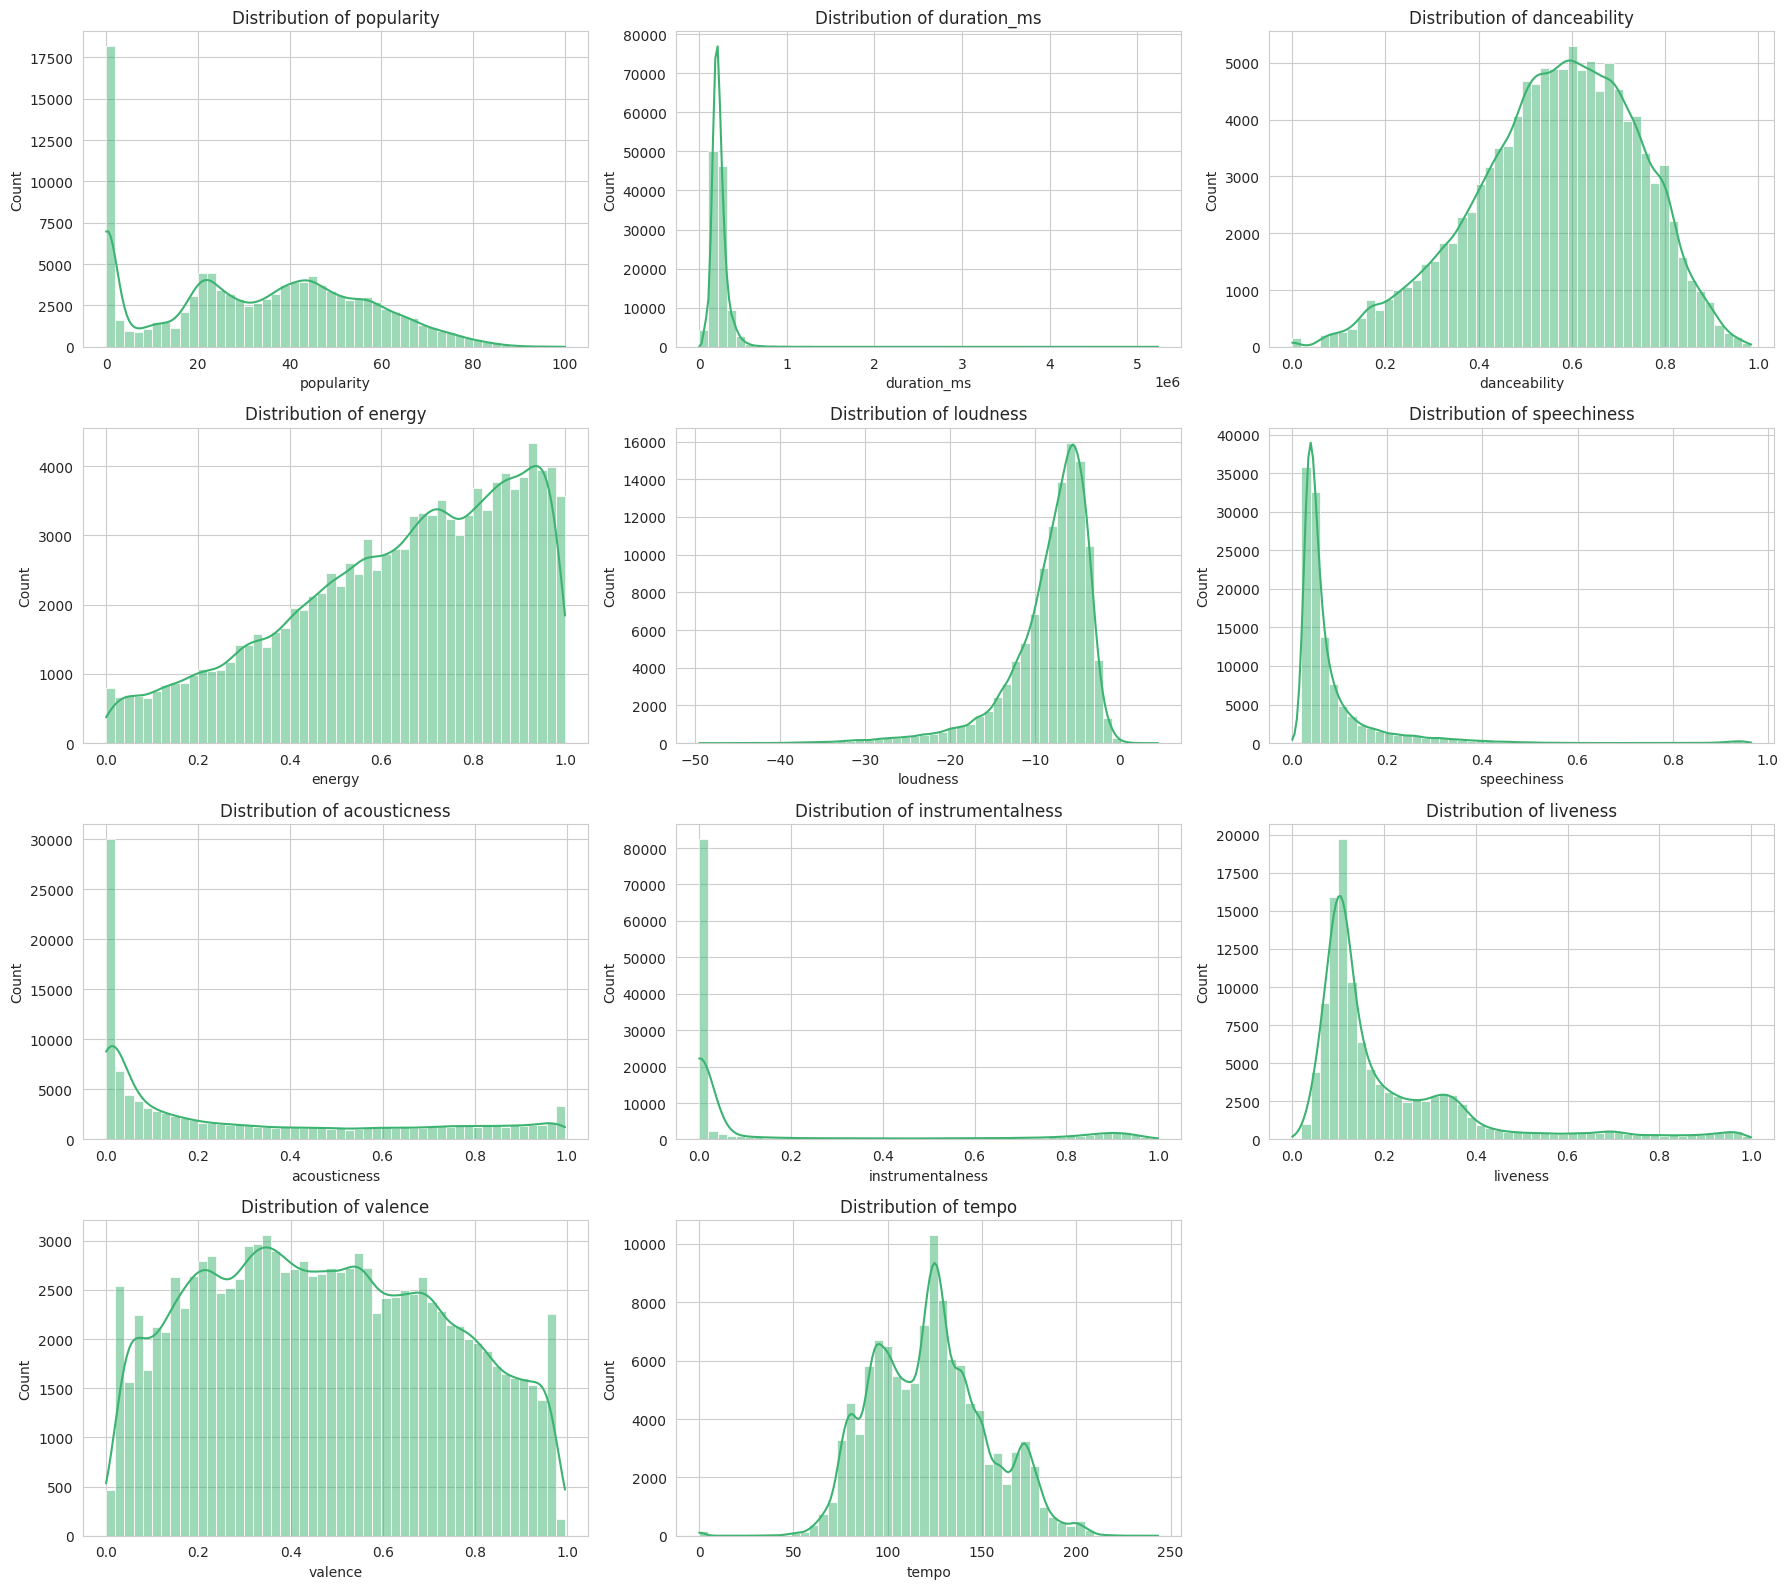

In [7]:
sns.set_style("whitegrid")

# Selected numeric features for plotting
numeric_features = ["popularity" , "duration_ms" , "danceability", "energy" , "loudness" , "speechiness" , "acousticness",
"instrumentalness", "liveness", "valence" , "tempo"]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18,16))
axes = axes.flatten()

# iterates over numeric_features and creates histogram of each feature's distribution
for i, feature in enumerate(numeric_features):
  sns.histplot(tracks_df[feature], bins=50, kde=True, ax=axes[i], color="mediumseagreen")
  axes[i].set_title(f"Distribution of {feature}")
  axes[i].set_xlabel(feature)
  axes[i].set_ylabel("Count")

# Removes any unused subplot axes
for j in range(len(numeric_features), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<Axes: >

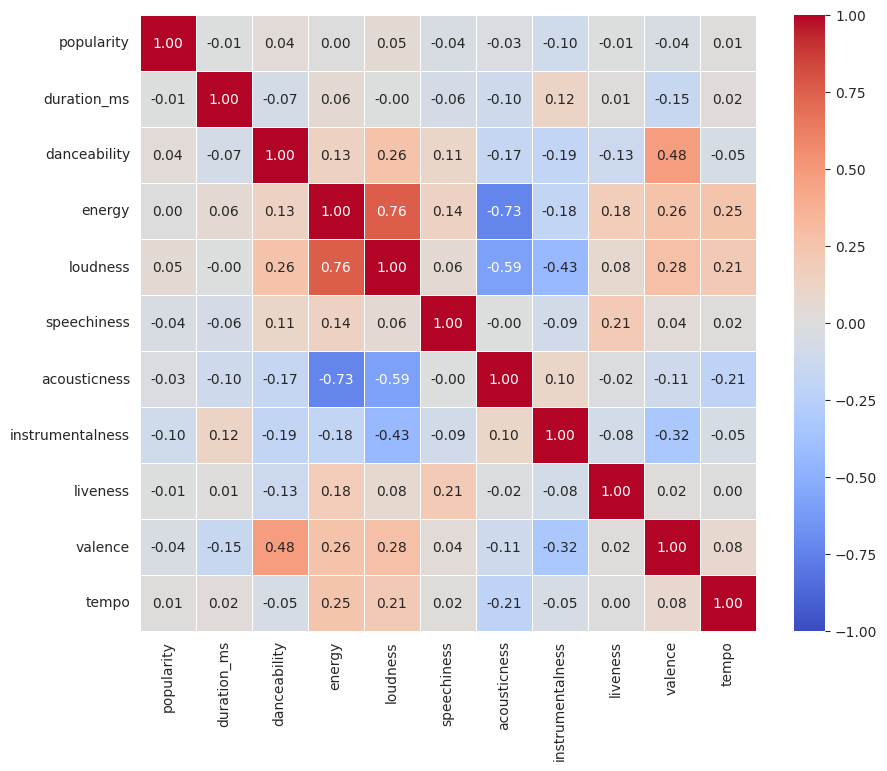

In [8]:
# Uses .corr() method to find correlation between features
corr_matrix = tracks_df[numeric_features].corr()

# Plots seaborn correlation heatmap between selected numeric features
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidth=0.5)



 # Correlation Heatmap Interpretation

 One strong relationship visible is between energy and loudness
 (0.76). This isn't surprising because both variables are related. An inverse correlation is present between acousticness and energy (-0.73). Other than these two relationships, there are moderate relationships (danceability and valence with 0.48 and acousticness and loudness with -0.59). Some key features that have little to no correlation with other features are population, speechiness, and liveness.

 The current 7 selected features are acousticness, danceability, energy, instrumentalness, liveness, speechiness, and valence. This leaves popularity, duration_ms, loudness, and tempo unused. Based on the dataset, correlation heatmap, and objective, tempo and popularity are good candidates to add because they have low correlation with other features, meaning they capture more independent and unique data, and are important metrics to improve the quality of song recommendations. Loudness has high correlation with energy and moderate correlation with acousticness, meaning it would capture redundant data, while duration is irrelevant to song preference.

# Select necessary features for clustering

We then select the features that we will use for clustering. These features are selected based on their relevance to the kind of music a person might like.

In [ ]:
# Select only necessary features for clustering
tracks = tracks_df[["acousticness","danceability","energy","instrumentalness","liveness","speechiness","valence"]]

# Initialize and train the KMeans model

Here, we initialize the KMeans model with 5 clusters. This means that we aim to divide our data into 5 different groups. We then train our model using the selected features.

In [10]:
#optimal number of clusters determined with elbow method
#instead of keeping the arbitrary value of 5 used in the orignal notebook, we found a k supported by the SSE curve.
sse = []
k_rng = range(1,11)
for k in k_rng:
  km = KMeans(n_clusters=k)
  km.fit(tracks_clean)
  sse.append(km.inertia_)

#elbow plot
plt.figure(figsize=(12,6))
plt.plot(k_rng, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of squared error')
plt.title('Elbow Plot for Optimal k')
plt.show()

In [11]:
# Train the model with our data
kmeans.fit(tracks)

KMeans(n_clusters=5)

# Assign cluster numbers to each track

After training the model, we add a new column to our DataFrame that represents the cluster each track belongs to. This is done using the labels_ attribute of the KMeans model.

In [12]:
# Add a new column 'type' to the dataframe. This column will contain the cluster number each track belongs to.
tracks_df["type"] = kmeans.labels_

In [13]:
tracks_df["type"]

,type
0,1
1,0
2,4
3,0
4,0
...,...
113995,0
113996,0
113997,0
113998,4


In [14]:
tracks_df.shape

(114000, 22)

# Save the DataFrame as a new CSV file

Once we have the cluster information added to our DataFrame, we save it as a new CSV file. This way, we don't have to perform the clustering every time we want to make a recommendation.

In [15]:
# Save the dataframe with cluster information as a new CSV file
tracks_df.to_csv("result.csv", index=False)

# Load the updated data with cluster info
tracks = pd.read_csv("result.csv")

In [16]:
tracks.head(13)

,UID,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,type
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,1
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,0
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,4
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,0
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,0
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic,1
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic,0
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic,1
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic,1
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic,4


# User input for favorite songs

Here, we prompt the user to enter the ids of their favorite songs. The ids should be separated by commas.

In [ ]:
# Prompt the user to enter their favorite songs' ids
ids = input('Enter comma-separated ids of your favorite songs\n> ').strip().split(',')

In [ ]:
#Trim whitespace from each ID and convert to integers
ids = [int(id.strip()) for id in ids]

# Print the entered IDs from the 'UID' column (for debugging purposes)
print("Entered IDs:", ids)

In [ ]:
# Filter the dataframe to get the user's favorite songs
favorites = tracks[tracks['UID'].isin(ids)]

In [ ]:
favorites

# Identify the user's favorite cluster

After getting the user's favorite songs, we identify the cluster that these songs most frequently belong to. This is done by counting the occurrences of each cluster number in the 'type' column of the user's favorite songs.

In [ ]:
# Find out the most frequent cluster among the user's favorite songs
clusters = favorites['type'].value_counts()
user_favorite_cluster = clusters.idxmax()

print('\nFavorite cluster:', user_favorite_cluster, '\n')

# Make song recommendations

Finally, we make song recommendations based on the user's favorite cluster. We do this by filtering our DataFrame to only include songs that belong to this cluster. We then print the first 5 songs as recommendations.

In [ ]:
# Get the songs that belong to the user's favorite cluster
suggestions = tracks[tracks['type'] == user_favorite_cluster]

# Print the first 5 song suggestions
suggestions.head()